# Guedes-Oliveira et al. (2019): a constrained mixture design for reduced-fat lamb patties

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | Guedes-Oliveira, J. M., Costa-Lima, B. R. C., Oliveira, D., Neto, A. C., Deliza, R., Conte-Junior, C. A., & Guimarães, C. F. M. (2019). *Mixture design approach for the development of reduced fat lamb patties with carboxymethyl cellulose and inulin*. **Food Science & Nutrition, 7**, 1328–1336. |
| DOI | [10.1002/fsn3.965](https://doi.org/10.1002/fsn3.965) |
| Open-access route | [PubMed Central, PMC6475733](https://pmc.ncbi.nlm.nih.gov/articles/PMC6475733/) |
| Licence | [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) |
| Citation snapshot | 25 Crossref citations, retrieved 2026-08-01 from the DOI record |
| Reproduction level | **Level C — methodological reproduction** |
| Random seed | `20190219` |
| Core tools | `pydoe`, `numpy`, `pandas`, `scipy`, `matplotlib` |

**What is reproduced exactly.** Table 1's 13 printed formulations, the underlying simplex-lattice plus axial mixture geometry, Table 2's published quadratic Scheffé coefficients and interaction p-values, coefficient-derived response surfaces, the preferred formulation's published liking and calorie values, and the CATA counts used below.

**What cannot be reproduced exactly.** The article does not publish row-level instrumental responses, the three centre-batch outcomes, model ANOVA, standard errors, residuals, or supplemental data. Consequently, this notebook **does not refit the response models**, independently reproduce coefficients or p-values, calculate pure-error/lack-of-fit tests, or validate response uncertainty. Published coefficients are evaluated as reported surfaces. No observations are invented.

This is intentionally a Level C case because mixture geometry and constrained Scheffé modelling add a design concept not covered by the Box–Behnken, Taguchi, or DoE/ML notebooks in this collection.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
from importlib.metadata import version
from pathlib import Path
import hashlib
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from pydoe import mixture_axial_design, simplex_lattice_design

SEED = 20190219
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 5)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})

VERSIONS = {p: version(p) for p in ["pydoe", "numpy", "pandas", "scipy", "matplotlib"]}
VERSIONS

{'pydoe': '1.3.1.dev11+geca1a2598',
 'numpy': '2.3.4',
 'pandas': '3.0.0',
 'scipy': '1.16.2',
 'matplotlib': '3.11.1'}

## 1. Scientific context

The study replaced part of the fat phase in lamb patties with carboxymethyl cellulose (CMC) and inulin. The three blend components—fat, CMC, and inulin—always total **10% w/w of the formulation**, while fat is constrained to at least **5%**. Changing one component necessarily changes at least one other, so an ordinary factorial design with independently varied factors would be physically impossible. A mixture design is appropriate because the scientific question concerns **proportions**, not three independent doses.

- **Experimental unit:** most defensibly, a separately prepared formulation batch. Ten patties per formulation were instrumentally assessed, but these appear to be subsamples, not ten independently prepared batches.
- **Replication:** the centroid formulation was reportedly prepared three times; Table 1 displays it once. Thus the experiment plausibly contained 15 batches but only 13 unique formulations. The individual replicate responses are unavailable.
- **Blocks and run randomization:** not reported for the instrumental experiment. Four sensory samples were presented to 100 consumers using a Williams Latin square; that presentation design is separate from the mixture regression.
- **Responses:** texture-profile variables, instrumental colour, cooking weight loss, diameter reduction, sensory liking/CATA attributes, and calculated energy value.
- **Primary constraint:** fat + CMC + inulin = 10% and fat ≥ 5%. The authors later advise CMC ≤ 1% for sensory quality; that is a downstream practical constraint, not the original design-space boundary.

The model-space implication is crucial: within the full 10% blend, the CMC-only and inulin-only vertices are prohibited. Their linear Scheffé coefficients therefore refer to extrapolated pure-component vertices, not observed formulations.

## 2. Data provenance and reproduction boundary

The values below are manually transcribed from the open-access article:

- `mixtures`: Table 1, preserving the printed one-decimal percentages and run labels;
- `coefficients`: Table 2, with response units from the methods/table headings;
- `interaction_p`: the three reported interaction p-values in Table 2;
- `consumer` and `calories`: selected values from Tables 3–5.

Four ambiguities are retained and documented:

1. Methods print `final weight / initial weight × 100` as *weight loss*. That is cooking yield/retention. Figure 4 and the narrative use smaller values as less loss, so the intended loss formula is almost certainly `(initial − final) / initial × 100`.
2. Equation (1) includes a special-cubic $b_{123}x_1x_2x_3$ term, but Table 2 reports only the six quadratic Scheffé coefficients. We cannot tell whether the cubic term was fitted and removed or merely omitted.
3. M8 is 5.9% fat in Table 1 (which preserves the 10% closure) but 5.8% in the conclusion, consistent with independently rounding its nominal 5.833…% value.
4. Table 2 prints the inulin gumminess coefficient as `25.537`, while neighbouring gumminess coefficients use a thousands-scale convention and the published contour has that scale. We evaluate it as **25,537** and retain the source string in `source_note`; this is an interpretation, not a silent correction.

In [2]:
mixtures = pd.DataFrame(
    [
        (1, 6.7, 3.3, 0.0), (2, 5.0, 5.0, 0.0), (3, 8.3, 1.7, 0.0),
        (4, 5.0, 1.7, 3.3), (5, 6.6, 1.7, 1.7), (6, 10.0, 0.0, 0.0),
        (7, 5.9, 3.3, 0.8), (8, 5.9, 0.8, 3.3), (9, 6.7, 0.0, 3.3),
        (10, 8.3, 0.0, 1.7), (11, 5.0, 0.0, 5.0), (12, 5.0, 3.3, 1.7),
        (13, 8.4, 0.8, 0.8),
    ],
    columns=["mixture", "FAT_pct", "CMC_pct", "IN_pct"],
).set_index("mixture")

coef_rows = [
    ("Hardness", "N", 327, 1534, 462, -3269, -320, -3219),
    ("Adhesiveness", "g·s", -14, 361, 414, -592, -1012, -520),
    ("Chewiness", "g·mm", 9882, 49967, 15208, -111329, -14623, -103794),
    ("Gumminess", "N", 13764, 66913, 25537, -149059, -30107, -135957),
    ("Springiness", "mm", 0.723, 1.640, 0.042, -3.425, 1.328, -3.199),
    ("Cohesiveness", "ratio", 0.405, 1.158, 0.594, -2.580, -0.561, -2.216),
    ("L*", "CIELAB", 46.546, 50.703, 49.432, 0.478, -8.708, 16.196),
    ("a*", "CIELAB", 13.49, -2.04, 21.42, 24.94, -20.80, 23.63),
    ("b*", "CIELAB", 17.289, 7.286, 19.371, 20.339, -7.642, 16.814),
    ("Diameter reduction", "%", 33.31, 46.81, 41.58, -70.78, -35.25, 21.14),
    ("Weight loss", "g/100 g", 36.40, 103.9, 47.6, -212, -25.8, -127),
]
coefficients = pd.DataFrame(
    coef_rows,
    columns=["response", "unit", "FAT", "CMC", "IN", "FAT×CMC", "FAT×IN", "CMC×IN"],
).set_index("response")
coefficients["source_note"] = ""
coefficients.loc["Gumminess", "source_note"] = "Article prints IN as '25.537'; evaluated as 25,537."

interaction_p = pd.DataFrame(
    [
        ("Hardness", .010, .740, .010), ("Adhesiveness", .733, .563, .764),
        ("Chewiness", .014, .681, .019), ("Gumminess", .014, .532, .021),
        ("Springiness", .017, .269, .023), ("Cohesiveness", .010, .469, .019),
        ("L*", .990, .824, .680), ("a*", .306, .388, .330),
        ("b*", .107, .510, .170), ("Diameter reduction", .204, .508, .688),
        ("Weight loss", .035, .760, .161),
    ],
    columns=["response", "FAT×CMC", "FAT×IN", "CMC×IN"],
).set_index("response")

consumer = pd.DataFrame(
    {
        "overall_liking_mean": [6.4, 6.3, 6.2, 7.8],
        "firm_texture": [18, 16, 14, 65], "residual_flavor": [20, 21, 24, 4],
        "tasty": [57, 51, 47, 82], "crumbly": [34, 41, 41, 4],
        "fatty": [54, 53, 57, 16], "residual_fat": [40, 60, 59, 12],
        "pleasant_aroma": [52, 52, 45, 62], "homogeneous": [14, 12, 11, 32],
    }, index=pd.Index([3, 4, 5, 8], name="mixture")
)
calories = pd.Series([217.3, 170.2, 201.9, 191.1], index=[3, 4, 5, 8], name="kcal_per_100g")

# Integrity checks on the manually transcribed design.
assert mixtures.shape == (13, 3)
assert np.allclose(mixtures.sum(axis=1), 10.0)
assert mixtures["FAT_pct"].min() == 5.0
assert mixtures.isna().sum().sum() == 0
assert mixtures.duplicated().sum() == 0

mixtures

,FAT_pct,CMC_pct,IN_pct
mixture,,,
1,6.7,3.3,0.0
2,5.0,5.0,0.0
3,8.3,1.7,0.0
4,5.0,1.7,3.3
5,6.6,1.7,1.7
6,10.0,0.0,0.0
7,5.9,3.3,0.8
8,5.9,0.8,3.3
9,6.7,0.0,3.3


## 3. Reconstruct the design

The 5% lower bound on fat makes the feasible triangle look asymmetric in physical percentages. Introduce **pseudo-components**

$$z_F=(FAT-5)/5,\qquad z_C=CMC/5,\qquad z_I=IN/5,$$

so $z_F+z_C+z_I=1$ and each pseudo-component lies in $[0,1]$. In this geometry, the nominal 13-point design is the union of a degree-3 simplex-lattice design (10 points) and the three non-centroid axial mixture points. `pydoe` generates both pieces. The published one-decimal formulations are matched to the nominal rows by a minimum-total-distance assignment; matching does not assume the paper's run order.

In [3]:
def physical_to_pseudo(frame):
    return np.column_stack([
        (frame["FAT_pct"].to_numpy() - 5.0) / 5.0,
        frame["CMC_pct"].to_numpy() / 5.0,
        frame["IN_pct"].to_numpy() / 5.0,
    ])

published_z = physical_to_pseudo(mixtures)
lattice_z = np.asarray(simplex_lattice_design(3, 3), dtype=float)
axial_z = np.asarray(mixture_axial_design(3, delta=0.5), dtype=float)

# Keep the three axial points and omit its duplicate centroid.
centroid = np.full(3, 1/3)
axial_noncentre = axial_z[~np.all(np.isclose(axial_z, centroid), axis=1)]
nominal_z = np.vstack([lattice_z, axial_noncentre])

assert lattice_z.shape == (10, 3)
assert axial_noncentre.shape == (3, 3)
assert nominal_z.shape == (13, 3)
assert np.allclose(nominal_z.sum(axis=1), 1)

distances = np.linalg.norm(published_z[:, None, :] - nominal_z[None, :, :], axis=2)
pub_idx, nom_idx = linear_sum_assignment(distances)
matched_nominal_z = nominal_z[nom_idx[np.argsort(pub_idx)]]

mapping = mixtures.copy()
for j, label in enumerate(["z_FAT", "z_CMC", "z_IN"]):
    mapping[label] = published_z[:, j]
    mapping[f"nominal_{label}"] = matched_nominal_z[:, j]
mapping["pseudo_distance"] = np.linalg.norm(published_z - matched_nominal_z, axis=1)
mapping["max_physical_abs_diff_pp"] = 5 * np.max(np.abs(published_z - matched_nominal_z), axis=1)

assert mapping["pseudo_distance"].max() < 0.017
mapping.round(5)

,FAT_pct,CMC_pct,IN_pct,z_FAT,nominal_z_FAT,z_CMC,nominal_z_CMC,z_IN,nominal_z_IN,pseudo_distance,max_physical_abs_diff_pp
mixture,,,,,,,,,,,
1,6.7,3.3,0.0,0.34,0.33333,0.66,0.66667,0.00,0.00000,0.00943,0.03333
2,5.0,5.0,0.0,0.00,0.00000,1.00,1.00000,0.00,0.00000,0.00000,0.00000
3,8.3,1.7,0.0,0.66,0.66667,0.34,0.33333,0.00,0.00000,0.00943,0.03333
4,5.0,1.7,3.3,0.00,0.00000,0.34,0.33333,0.66,0.66667,0.00943,0.03333
5,6.6,1.7,1.7,0.32,0.33333,0.34,0.33333,0.34,0.33333,0.01633,0.06667
6,10.0,0.0,0.0,1.00,1.00000,0.00,0.00000,0.00,0.00000,0.00000,0.00000
7,5.9,3.3,0.8,0.18,0.16667,0.66,0.66667,0.16,0.16667,0.01633,0.06667
8,5.9,0.8,3.3,0.18,0.16667,0.16,0.16667,0.66,0.66667,0.01633,0.06667
9,6.7,0.0,3.3,0.34,0.33333,0.00,0.00000,0.66,0.66667,0.00943,0.03333


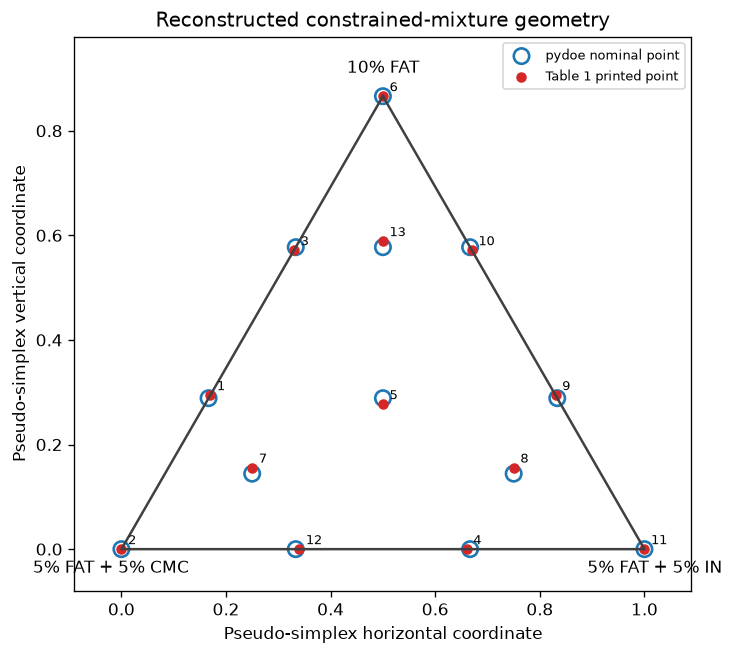

Maximum nominal-to-printed displacement: 0.01633 pseudo units
Maximum component discrepancy: 0.0667 percentage points


In [4]:
SQRT3 = np.sqrt(3)
VERTICES = np.array([[0.5, SQRT3/2], [0.0, 0.0], [1.0, 0.0]])  # FAT, CMC, IN

def ternary_xy(z):
    return np.asarray(z) @ VERTICES

fig, ax = plt.subplots(figsize=(7.2, 6.0))
triangle = VERTICES[[0, 1, 2, 0]]
ax.plot(triangle[:, 0], triangle[:, 1], color="0.25", lw=1.5)
nom_xy = ternary_xy(nominal_z)
pub_xy = ternary_xy(published_z)
ax.scatter(nom_xy[:, 0], nom_xy[:, 1], s=85, facecolors="none", edgecolors="#1f77b4",
           linewidths=1.6, label="pydoe nominal point")
ax.scatter(pub_xy[:, 0], pub_xy[:, 1], s=28, color="#d62728", label="Table 1 printed point")
for mix, (x, y) in zip(mixtures.index, pub_xy):
    ax.annotate(str(mix), (x, y), xytext=(4, 3), textcoords="offset points", fontsize=8)
ax.text(VERTICES[0, 0], VERTICES[0, 1] + .045, "10% FAT", ha="center")
ax.text(VERTICES[1, 0] - .02, VERTICES[1, 1] - .045, "5% FAT + 5% CMC", ha="center")
ax.text(VERTICES[2, 0] + .02, VERTICES[2, 1] - .045, "5% FAT + 5% IN", ha="center")
ax.set(title="Reconstructed constrained-mixture geometry", xlabel="Pseudo-simplex horizontal coordinate",
       ylabel="Pseudo-simplex vertical coordinate", aspect="equal")
ax.legend(loc="upper right", fontsize=8)
ax.set_xlim(-.09, 1.09); ax.set_ylim(-.08, .98)
plt.show()

print(f"Maximum nominal-to-printed displacement: {mapping['pseudo_distance'].max():.5f} pseudo units")
print(f"Maximum component discrepancy: {mapping['max_physical_abs_diff_pp'].max():.4f} percentage points")

The red dots almost cover the generated open circles. Their maximum component discrepancy is only about 0.067 percentage points: it is the expected effect of printing a thirds-based design to one decimal while forcing every displayed row to sum exactly to 10%. The plot is a geometric reconstruction, **not** a response plot. Table order is a formulation identifier; no randomized execution order is reported.

The nominal centroid is (6.667, 1.667, 1.667)%, printed as (6.6, 1.7, 1.7)% in M5. The paper says this setting was prepared three times. If all three were independently prepared batches, the quadratic model would have 15 observations, 6 coefficients, 9 residual degrees of freedom, 2 pure-error degrees of freedom, and 7 lack-of-fit degrees of freedom. Without those responses, that decomposition cannot be calculated.

## 4. Understand the design

For component proportions $x_F=FAT/10$, $x_C=CMC/10$, and $x_I=IN/10$, the quadratic Scheffé model is

$$E(Y)=b_Fx_F+b_Cx_C+b_Ix_I+b_{FC}x_Fx_C+b_{FI}x_Fx_I+b_{CI}x_Cx_I.$$

It has no ordinary intercept: because the proportions sum to one, an intercept plus all three linear terms would be redundant. The interaction terms describe curvature away from linear blending. The article's equation also prints $b_{FCI}x_Fx_Cx_I$; adding it produces a seven-parameter special-cubic model.

In [5]:
def actual_components(frame_or_array):
    # Return FAT, CMC, IN as fractions of their fixed 10% blend.
    arr = frame_or_array.to_numpy() if hasattr(frame_or_array, "to_numpy") else np.asarray(frame_or_array)
    return arr / arr.sum(axis=1, keepdims=True)

def scheffe_quadratic(x):
    x = np.asarray(x)
    return np.column_stack([x[:, 0], x[:, 1], x[:, 2],
                            x[:, 0]*x[:, 1], x[:, 0]*x[:, 2], x[:, 1]*x[:, 2]])

def scheffe_special_cubic(x):
    x = np.asarray(x)
    return np.column_stack([scheffe_quadratic(x), x[:, 0]*x[:, 1]*x[:, 2]])

design_x = actual_components(mixtures)
Xq = scheffe_quadratic(design_x)
Xc = scheffe_special_cubic(design_x)
info_eigenvalues = np.linalg.eigvalsh(Xq.T @ Xq)
hat = Xq @ np.linalg.inv(Xq.T @ Xq) @ Xq.T

diagnostics = pd.Series({
    "quadratic_rank": np.linalg.matrix_rank(Xq),
    "quadratic_parameters": Xq.shape[1],
    "quadratic_condition_number": np.linalg.cond(Xq),
    "special_cubic_rank": np.linalg.matrix_rank(Xc),
    "special_cubic_parameters": Xc.shape[1],
    "special_cubic_condition_number": np.linalg.cond(Xc),
    "sum_of_leverages": np.diag(hat).sum(),
    "maximum_leverage": np.diag(hat).max(),
})
display(diagnostics.to_frame("value"))
display(pd.DataFrame({"information_eigenvalue": info_eigenvalues}, index=range(1, 7)))
display(pd.DataFrame({"leverage": np.diag(hat)}, index=mixtures.index).sort_values("leverage", ascending=False))

,value
quadratic_rank,6.00000
quadratic_parameters,6.00000
quadratic_condition_number,52.40487
special_cubic_rank,7.00000
special_cubic_parameters,7.00000
special_cubic_condition_number,689.43271
sum_of_leverages,6.00000
maximum_leverage,0.85444


,information_eigenvalue
1,0.00251
2,0.00333
3,0.00428
4,0.37258
5,0.63202
6,6.90520


,leverage
mixture,
2,0.85444
11,0.85444
6,0.84139
12,0.44647
4,0.44647
3,0.43837
10,0.43837
1,0.43752
9,0.43752


All six quadratic coefficients are estimable at the 13 unique settings. The information eigenvalues are positive, but not equal: constrained mixture geometry is not orthogonal in this basis. M2, M11, and M6 sit at feasible vertices and have the highest leverage; they anchor the surface.

The special-cubic column is technically estimable, yet its much larger condition number shows that it is weakly separated from the quadratic terms. With no raw responses, there is no defensible way to decide whether the paper fitted that term, dropped it, or omitted it from Table 2. The notebook therefore evaluates exactly the six coefficients actually reported.

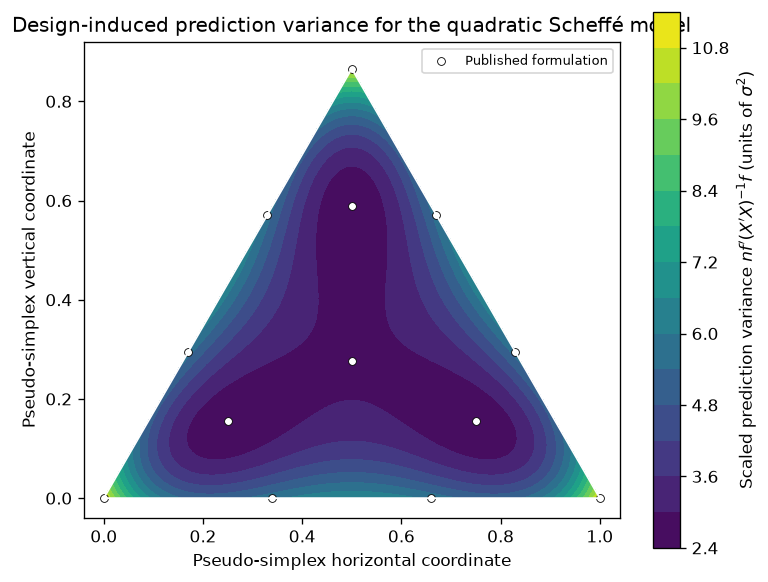

In [6]:
def simplex_grid(degree=80):
    z = []
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            z.append((i/degree, j/degree, 1 - (i+j)/degree))
    return np.asarray(z)

grid_z = simplex_grid(80)
grid_physical = np.column_stack([5 + 5*grid_z[:, 0], 5*grid_z[:, 1], 5*grid_z[:, 2]])
grid_x = actual_components(grid_physical)
grid_xy = ternary_xy(grid_z)

inv_info = np.linalg.inv(Xq.T @ Xq)
grid_f = scheffe_quadratic(grid_x)
scaled_prediction_variance = len(mixtures) * np.einsum("ij,jk,ik->i", grid_f, inv_info, grid_f)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
cn = ax.tricontourf(grid_xy[:, 0], grid_xy[:, 1], scaled_prediction_variance, levels=16, cmap="viridis")
ax.plot(triangle[:, 0], triangle[:, 1], color="white", lw=1.1)
ax.scatter(pub_xy[:, 0], pub_xy[:, 1], s=22, color="white", edgecolor="black", linewidth=.5,
           label="Published formulation")
fig.colorbar(cn, ax=ax, label=r"Scaled prediction variance $n f'(X'X)^{-1}f$ (units of $\sigma^2$)")
ax.set(title="Design-induced prediction variance for the quadratic Scheffé model",
       xlabel="Pseudo-simplex horizontal coordinate", ylabel="Pseudo-simplex vertical coordinate", aspect="equal")
ax.legend(fontsize=8)
ax.set_xlim(-.04, 1.04); ax.set_ylim(-.04, .92)
plt.show()

This map depends only on the design matrix, not on unavailable responses. It expresses model-prediction variance in units of the unknown residual variance $\sigma^2$. It is smallest where the design supports the fitted basis well and largest near influential boundaries. Because $sigma^2$ is unavailable, absolute confidence intervals cannot be drawn.

## 5. Reproduce the article analysis

The article's contour ranges reveal that Table 2 uses the three components as proportions of the 10% blend—for example, M8 is $(0.59, 0.08, 0.33)$—rather than the lower-bound pseudo-components. We evaluate each printed coefficient vector on that scale. These are **published-model predictions**, not refits or observed responses.

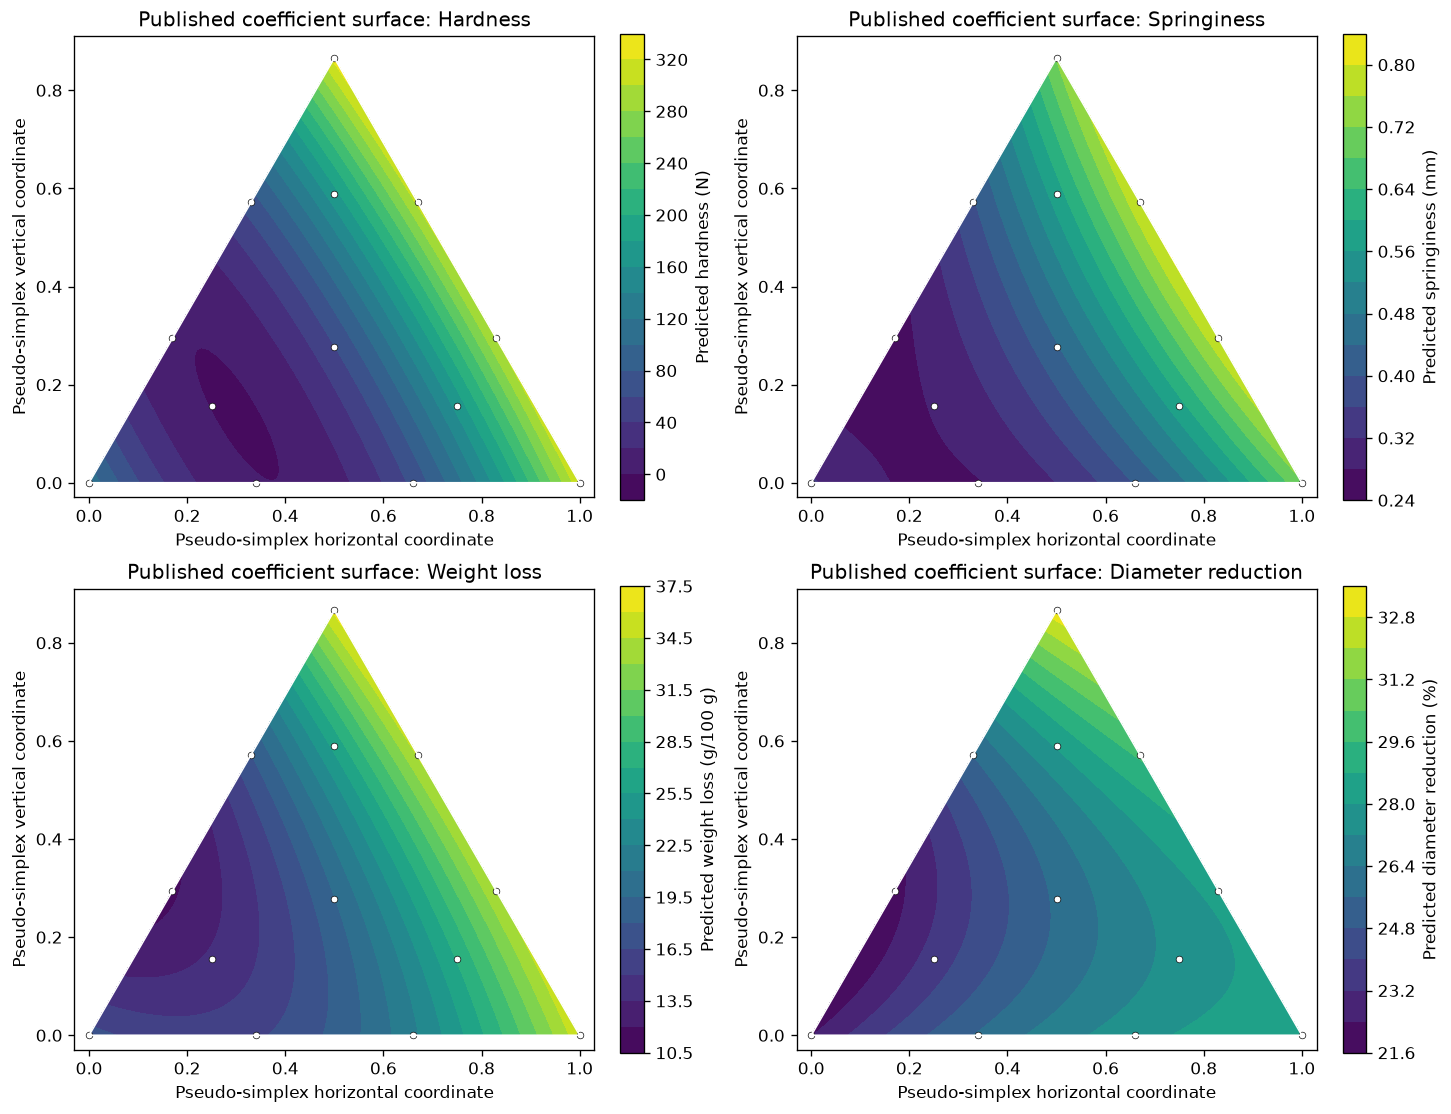

,reproduced_min,reproduced_max
Hardness,-1.90590,327.0000
Springiness,0.26389,0.8018
Weight loss,11.77891,36.4000
Diameter reduction,21.72146,33.3100


In [7]:
COEF_COLUMNS = ["FAT", "CMC", "IN", "FAT×CMC", "FAT×IN", "CMC×IN"]

def predict_published(response, x):
    beta = coefficients.loc[response, COEF_COLUMNS].astype(float).to_numpy()
    return scheffe_quadratic(x) @ beta

surface_responses = ["Hardness", "Springiness", "Weight loss", "Diameter reduction"]
fig, axes = plt.subplots(2, 2, figsize=(12.0, 9.2), constrained_layout=True)
for ax, response in zip(axes.flat, surface_responses):
    values = predict_published(response, grid_x)
    cn = ax.tricontourf(grid_xy[:, 0], grid_xy[:, 1], values, levels=16, cmap="viridis")
    ax.plot(triangle[:, 0], triangle[:, 1], color="white", lw=1.0)
    ax.scatter(pub_xy[:, 0], pub_xy[:, 1], s=16, color="white", edgecolor="black", linewidth=.4)
    unit = coefficients.loc[response, "unit"]
    fig.colorbar(cn, ax=ax, label=f"Predicted {response.lower()} ({unit})")
    ax.set(title=f"Published coefficient surface: {response}", xlabel="Pseudo-simplex horizontal coordinate",
           ylabel="Pseudo-simplex vertical coordinate", aspect="equal")
    ax.set_xlim(-.03, 1.03); ax.set_ylim(-.03, .91)
plt.show()

surface_ranges = pd.DataFrame({
    "reproduced_min": [predict_published(r, grid_x).min() for r in surface_responses],
    "reproduced_max": [predict_published(r, grid_x).max() for r in surface_responses],
}, index=surface_responses)
surface_ranges

The surfaces reproduce the qualitative published legends: hardness spans below 60 to above 300 N, springiness below 0.30 to above 0.78 mm, weight loss below 15 to above 35 g/100 g, and diameter reduction below 22% to above 32%. A small region of the hardness model even dips below zero, which is physically impossible. That is a warning about response-model form and uncertainty, not evidence for negative hardness; a point can lie inside the mixture triangle while a poorly supported polynomial prediction remains scientifically implausible.

In [8]:
sig = interaction_p.copy()
sig.columns = pd.MultiIndex.from_arrays([sig.columns, ["p-value"]*3])
display(sig.style.map(lambda v: "font-weight: bold; color: #b22222" if v < .05 else ""))

m8_x = actual_components(mixtures.loc[[8]])
m8_predictions = pd.DataFrame({
    "published_surface_prediction": [predict_published(r, m8_x)[0] for r in coefficients.index],
    "unit": coefficients["unit"],
})
m8_predictions

,FAT×CMC,FAT×IN,CMC×IN
,p-value,p-value,p-value
response,,,
Hardness,0.010000,0.740000,0.010000
Adhesiveness,0.733000,0.563000,0.764000
Chewiness,0.014000,0.681000,0.019000
Gumminess,0.014000,0.532000,0.021000
Springiness,0.017000,0.269000,0.023000
Cohesiveness,0.010000,0.469000,0.019000
L*,0.990000,0.824000,0.680000
a*,0.306000,0.388000,0.330000


,published_surface_prediction,unit
response,,
Hardness,166.52760,N
Adhesiveness,-81.46680,g·s
Chewiness,4004.39150,g·mm
Gumminess,5414.32750,N
Springiness,0.58408,mm
Cohesiveness,0.23810,ratio
L*,46.58563,CIELAB
a*,12.61574,CIELAB
b*,17.09181,CIELAB


The significant reported interactions are FAT×CMC and CMC×IN for hardness, chewiness, gumminess, springiness, and cohesiveness; only FAT×CMC is reported significant for weight loss. These p-values are transcriptions, not independently reproduced tests. Linear-term p-values were not reported because all linear blend terms are required by the mixture parameterization.

For M8, the table above is a deterministic evaluation of Table 2's coefficients at the Table 1 composition. It must not be mistaken for a measured M8 result or a confidence-bearing confirmation prediction.

## 6. Validate against the paper

Numerical validation is deliberately limited to quantities that can be checked from published inputs. Legend bands are treated as coarse graphical targets, not precise observations.

In [9]:
validation = pd.DataFrame([
    ("Unique formulations", 13, len(mixtures), 0, 0, "exact", "Table 1"),
    ("Blend total for every row (%)", 10.0, mixtures.sum(axis=1).min(), 0, 0, "exact", "closure assertion"),
    ("Fat lower bound (%)", 5.0, mixtures["FAT_pct"].min(), 0, 0, "exact", "constraint assertion"),
    ("Maximum nominal/printed component deviation (percentage points)", 0.1,
     mapping["max_physical_abs_diff_pp"].max(), np.nan, np.nan, "≤ 0.1", "rounding tolerance"),
    ("M8 fat in Table 1 (%)", 5.9, mixtures.loc[8, "FAT_pct"], 0, 0, "exact", "conclusion instead says 5.8"),
    ("M8 overall liking mean", 7.8, consumer.loc[8, "overall_liking_mean"], 0, 0, "exact", "Table 3 transcription"),
    ("M8 energy (kcal/100 g)", 191.1, calories.loc[8], 0, 0, "exact", "Table 5 transcription"),
    ("Hardness legend coverage (N)", "<60 to >300",
     f"{surface_ranges.loc['Hardness','reproduced_min']:.2f} to {surface_ranges.loc['Hardness','reproduced_max']:.2f}",
     np.nan, np.nan, "spans both thresholds", "Figure 2"),
    ("Springiness legend coverage (mm)", "<0.30 to >0.78",
     f"{surface_ranges.loc['Springiness','reproduced_min']:.3f} to {surface_ranges.loc['Springiness','reproduced_max']:.3f}",
     np.nan, np.nan, "spans both thresholds", "Figure 2"),
    ("Weight-loss legend coverage (g/100 g)", "<15 to >35",
     f"{surface_ranges.loc['Weight loss','reproduced_min']:.2f} to {surface_ranges.loc['Weight loss','reproduced_max']:.2f}",
     np.nan, np.nan, "spans both thresholds", "Figure 4"),
    ("Diameter-reduction legend coverage (%)", "<22 to >32",
     f"{surface_ranges.loc['Diameter reduction','reproduced_min']:.2f} to {surface_ranges.loc['Diameter reduction','reproduced_max']:.2f}",
     np.nan, np.nan, "spans both thresholds", "Figure 4"),
], columns=["target", "published", "reproduced", "absolute_difference", "relative_difference", "tolerance", "note"])
validation

,target,published,reproduced,absolute_difference,relative_difference,tolerance,note
0,Unique formulations,13,13,0.0,0.0,exact,Table 1
1,Blend total for every row (%),10.0,10.0,0.0,0.0,exact,closure assertion
2,Fat lower bound (%),5.0,5.0,0.0,0.0,exact,constraint assertion
3,Maximum nominal/printed component deviation (p...,0.1,0.06667,NaN,NaN,≤ 0.1,rounding tolerance
4,M8 fat in Table 1 (%),5.9,5.9,0.0,0.0,exact,conclusion instead says 5.8
5,M8 overall liking mean,7.8,7.8,0.0,0.0,exact,Table 3 transcription
6,M8 energy (kcal/100 g),191.1,191.1,0.0,0.0,exact,Table 5 transcription
7,Hardness legend coverage (N),<60 to >300,-1.91 to 327.00,NaN,NaN,spans both thresholds,Figure 2
8,Springiness legend coverage (mm),<0.30 to >0.78,0.264 to 0.802,NaN,NaN,spans both thresholds,Figure 2
9,Weight-loss legend coverage (g/100 g),<15 to >35,11.78 to 36.40,NaN,NaN,spans both thresholds,Figure 4


**Cannot be validated from the article:** coefficient estimation, standard errors, interaction p-values, residual diagnostics, response transformations, the special-cubic decision, pure error, lack of fit, confidence intervals, and whether the ten patties per formulation entered the analysis as independent observations. Treating patty subsamples as independent batches would be pseudoreplication and would overstate precision.

The weight-loss equation is also not numerically recoverable from the methods as printed: `final/initial × 100` measures yield. The plotted 15–35 range and “lower loss” interpretation support the usual loss equation, `(initial − final)/initial × 100`, but raw weights are unavailable to verify it.

## 7. Go beyond the paper

### 7.1 Equal-budget design comparison

We compare the published 13-point design with 1,000 independent 13-point samples drawn uniformly from the **same constrained pseudo-simplex**. Both are judged for the same six-term quadratic Scheffé model and the same dense candidate grid.

- **D-information** is the geometric mean information per parameter; larger is better for joint coefficient precision.
- **Maximum scaled prediction variance** is a G-type worst-case criterion; smaller is better for uniform prediction.

This is a design-only teaching benchmark. It does not claim the response model is true.

In [10]:
def design_metrics(z_design):
    physical = np.column_stack([5 + 5*z_design[:, 0], 5*z_design[:, 1], 5*z_design[:, 2]])
    X = scheffe_quadratic(actual_components(physical))
    info = X.T @ X
    sign, logdet = np.linalg.slogdet(info / len(z_design))
    if sign <= 0 or np.linalg.matrix_rank(X) < X.shape[1]:
        return np.nan, np.inf
    d_information = np.exp(logdet / X.shape[1])
    inv = np.linalg.inv(info)
    max_var = len(z_design) * np.einsum("ij,jk,ik->i", grid_f, inv, grid_f).max()
    return d_information, max_var

published_metrics = design_metrics(published_z)
random_metrics = np.asarray([design_metrics(rng.dirichlet(np.ones(3), size=13)) for _ in range(1000)])
comparison = pd.DataFrame({
    "metric": ["D-information (larger is better)", "maximum scaled prediction variance (smaller is better)"],
    "published_design": published_metrics,
    "random_median": np.nanmedian(random_metrics, axis=0),
    "random_5th_percentile": np.nanpercentile(random_metrics, 5, axis=0),
    "random_95th_percentile": np.nanpercentile(random_metrics, 95, axis=0),
    "random_designs_beaten_by_published_pct": [
        100*np.mean(published_metrics[0] >= random_metrics[:, 0]),
        100*np.mean(published_metrics[1] <= random_metrics[:, 1]),
    ],
})
comparison

,metric,published_design,random_median,random_5th_percentile,random_95th_percentile,random_designs_beaten_by_published_pct
0,D-information (larger is better),0.00479,0.00164,0.00092,0.00254,100.0
1,maximum scaled prediction variance (smaller is...,11.10770,224.95271,53.81727,2026.25975,100.0


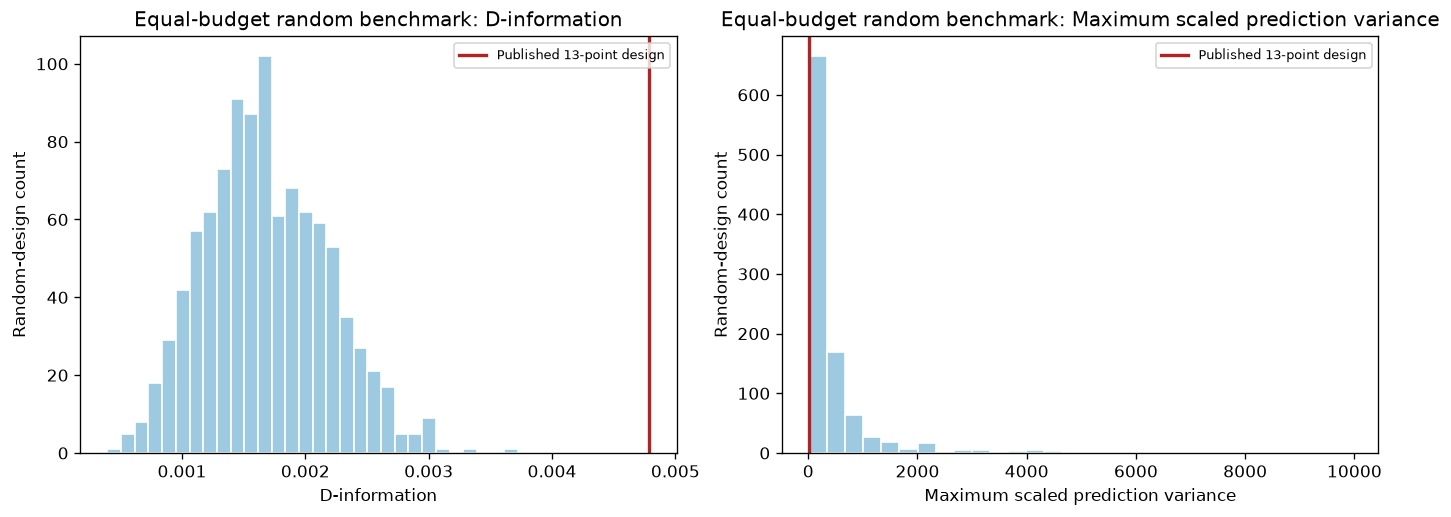

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
labels = ["D-information", "Maximum scaled prediction variance"]
for j, ax in enumerate(axes):
    vals = random_metrics[:, j]
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=30, color="#9ecae1", edgecolor="white")
    ax.axvline(published_metrics[j], color="#b22222", lw=2, label="Published 13-point design")
    ax.set(title=f"Equal-budget random benchmark: {labels[j]}", xlabel=labels[j], ylabel="Random-design count")
    ax.legend(fontsize=8)
plt.show()

The structured lattice/axial design is expected to beat most random samples because it deliberately anchors vertices, edges, and interior curvature. The two criteria can still disagree: coefficient precision and worst-case prediction are different objectives. A random mixture sample also provides no guaranteed replication for pure error.

### 7.2 Feasible coefficients and extrapolation

The linear coefficients $b_C$ and $b_I$ are the model values at hypothetical 100%-CMC and 100%-inulin blend vertices. Those points violate the study's fat ≥ 5% formulation constraint. Therefore, statements such as “CMC has the largest coefficient” must not be read as an observed pure-CMC response. Only predictions inside the constrained triangle are interpolation in mixture space; even there, uncertainty and polynomial misspecification remain.

### 7.3 Why M8 is a multi-response choice, not a single-surface optimum

The paper recommends keeping CMC at or below 1% for sensory quality. Among the published settings satisfying that rule, we can screen the *reported coefficient surfaces* for low weight loss and low diameter reduction. A point is Pareto-efficient if no other eligible formulation improves both. This is a notebook-derived teaching analysis—not the paper's optimization—and it carries no uncertainty because raw responses are unavailable.

In [12]:
design_surface = mixtures.copy()
for response in ["Weight loss", "Diameter reduction", "Hardness", "Springiness"]:
    design_surface[response] = predict_published(response, design_x)
design_surface["CMC_le_1pct"] = design_surface["CMC_pct"] <= 1.0

eligible = design_surface[design_surface["CMC_le_1pct"]].copy()
objectives = eligible[["Weight loss", "Diameter reduction"]].to_numpy()
dominated = np.zeros(len(eligible), dtype=bool)
for i in range(len(eligible)):
    dominated[i] = any(
        np.all(objectives[j] <= objectives[i]) and np.any(objectives[j] < objectives[i])
        for j in range(len(eligible)) if j != i
    )
eligible["Pareto_efficient"] = ~dominated
eligible["overall_liking_mean_if_tested"] = consumer["overall_liking_mean"]
eligible[["FAT_pct", "CMC_pct", "IN_pct", "Weight loss", "Diameter reduction",
          "Pareto_efficient", "overall_liking_mean_if_tested"]].round(3)

,FAT_pct,CMC_pct,IN_pct,Weight loss,Diameter reduction,Pareto_efficient,overall_liking_mean_if_tested
mixture,,,,,,,
6,10.0,0.0,0.0,36.400,33.310,False,NaN
8,5.9,0.8,3.3,27.114,27.473,True,7.8
9,6.7,0.0,3.3,34.392,28.245,False,NaN
10,8.3,0.0,1.7,34.664,29.742,False,NaN
11,5.0,0.0,5.0,35.550,28.632,False,NaN
13,8.4,0.8,0.8,25.903,28.062,True,NaN


In [13]:
tested_summary = pd.concat([consumer[["overall_liking_mean", "tasty", "crumbly", "fatty", "residual_fat"]], calories], axis=1)
tested_summary

,overall_liking_mean,tasty,crumbly,fatty,residual_fat,kcal_per_100g
3,6.4,57,34,54,40,217.3
4,6.3,51,41,53,60,170.2
5,6.2,47,41,57,59,201.9
8,7.8,82,4,16,12,191.1


M8 and M13 form the surface-based two-objective Pareto set under the ≤1% CMC rule: the printed model trades lower diameter reduction at M8 against lower predicted weight loss at M13. But only M8 was among these two points evaluated by consumers, and it achieved the highest reported overall liking (7.8/9), was selected “tasty” by 82/100 consumers, and had much lower crumbly/fatty/residual-fat counts than M3–M5. That evidence explains why the final recommendation cannot be reconstructed by minimizing one instrumental polynomial.

This comparison also exposes the statistical limit: sensory testing on four hand-selected mixtures cannot validate the entire 13-point instrumental response surface, and the instrumental model cannot substitute for consumer response.

## 8. Practitioner conclusions

- **What DoE made possible:** the constrained mixture design covered vertices, edges, and interior blends in 13 unique formulations, allowing all six quadratic Scheffé terms to be estimated. One-factor-at-a-time experimentation is incoherent here because increasing one component forces another to decrease and would miss blending curvature.
- **What is supported:** the published design supports a six-parameter quadratic basis. Reported FAT×CMC and CMC×IN interactions describe curvature, but their p-values cannot be audited without raw responses. A special-cubic term is estimable but ill-conditioned and undocumented.
- **Where prediction is trustworthy:** geometrically, within the fat ≥ 5% triangle and closest to well-supported design regions. Scientifically, trust is weaker than geometry alone suggests because residual variance, lack of fit, and batch-to-batch replication are unavailable. Negative predicted hardness demonstrates this distinction.
- **Replication lesson:** ten patties from one preparation are subsamples. Only independently prepared batches provide experimental replication. The reported triplicate centroid could separate pure error from lack of fit, but the necessary outcomes are absent.
- **Coefficient lesson:** mixture linear coefficients at infeasible pure-component vertices are extrapolations. Do not rank ingredient importance by coefficient magnitude alone.
- **Optimization lesson:** M8 is defensible as a sensory–instrumental compromise, not as the unique optimum of a single published surface. Desirability weights and uncertainty would be required for a reproducible multi-response optimum.
- **Integrity lesson:** preserve closure, use the stated component scaling, disclose the weight-loss formula inconsistency, and never fabricate the missing response table to force a Level A reproduction.

## 9. Reproducibility metadata

The next cell records the live interpreter, package versions, UTC execution date, random seed, and SHA-256 checksums of the two principal manually transcribed numeric tables. The checksum is over stable CSV serialization, not over notebook output formatting.

In [14]:
def dataframe_sha256(frame):
    payload = frame.to_csv(index=True, lineterminator="\n").encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

metadata = pd.Series({
    "python": platform.python_version(),
    **{f"package_{k}": v for k, v in VERSIONS.items()},
    "random_seed": SEED,
    "execution_date_utc": pd.Timestamp.now(tz="UTC").date().isoformat(),
    "mixtures_sha256": dataframe_sha256(mixtures),
    "coefficients_sha256": dataframe_sha256(coefficients),
    "article_doi": "10.1002/fsn3.965",
    "reproduction_level": "C — methodological reproduction",
})
metadata.to_frame("value")

,value
python,3.13.2
package_pydoe,1.3.1.dev11+geca1a2598
package_numpy,2.3.4
package_pandas,3.0.0
package_scipy,1.16.2
package_matplotlib,3.11.1
random_seed,20190219
execution_date_utc,2026-08-01
mixtures_sha256,57143c8db3af6eb4cdc6f67ee7db536a04887dde681c02...
coefficients_sha256,5b1e13e06196dcca71b1ca7970eafed6105fc195b3a10f...
